In [1]:
%pip install matplotlib tensorflow scikit-learn seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D,BatchNormalization


In [3]:
train_path = "train"
test_path = "test"
organized_dir = "data"


In [4]:
def count_images_in_folder(folder_path):
    cat_count = 0
    dog_count = 0

    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        return 0, 0

    for filename in os.listdir(folder_path):
        name = filename.lower()
        if name.startswith("cat"):
            cat_count += 1
        elif name.startswith("dog"):
            dog_count += 1

    return cat_count, dog_count

train_cat_count, train_dog_count = count_images_in_folder(train_path)
print(f"Training Set: Dogs - {train_dog_count}, Cats - {train_cat_count}")


Training Set: Dogs - 12500, Cats - 12500


In [5]:
# Split raw training images into train/validation lists
from sklearn.model_selection import train_test_split

all_images = [
    img for img in os.listdir(train_path)
    if os.path.isfile(os.path.join(train_path, img))
]

dogs = [img for img in all_images if img.lower().startswith("dog")]
cats = [img for img in all_images if img.lower().startswith("cat")]

print(f"Found {len(dogs)} dog images and {len(cats)} cat images in {train_path}/")

dog_train, dog_val = train_test_split(dogs, test_size=0.2, random_state=42)
cat_train, cat_val = train_test_split(cats, test_size=0.2, random_state=42)


Found 12500 dog images and 12500 cat images in train/


In [6]:
# Helper for copying files
import shutil

def copy_files(file_list, src_dir, dest_dir):
    os.makedirs(dest_dir, exist_ok=True)
    for file in file_list:
        shutil.copy2(os.path.join(src_dir, file), os.path.join(dest_dir, file))


In [7]:
# Create a Jupyter-friendly working directory
train_organized_dir = os.path.join(organized_dir, "train")
val_organized_dir = os.path.join(organized_dir, "validation")

# Remove any old split so rerunning the notebook does not duplicate files
if os.path.exists(organized_dir):
    shutil.rmtree(organized_dir)

os.makedirs(os.path.join(train_organized_dir, "cats"), exist_ok=True)
os.makedirs(os.path.join(train_organized_dir, "dogs"), exist_ok=True)
os.makedirs(os.path.join(val_organized_dir, "cats"), exist_ok=True)
os.makedirs(os.path.join(val_organized_dir, "dogs"), exist_ok=True)

print("Created:")
print(train_organized_dir)
print(val_organized_dir)


Created:
data\train
data\validation


In [8]:
copy_files(dog_train, train_path, os.path.join(train_organized_dir, "dogs"))
copy_files(dog_val, train_path, os.path.join(val_organized_dir, "dogs"))
copy_files(cat_train, train_path, os.path.join(train_organized_dir, "cats"))
copy_files(cat_val, train_path, os.path.join(val_organized_dir, "cats"))

print("Finished copying files.")


Finished copying files.


In [9]:
# Count the number of images in each class
dog_count = len(os.listdir(os.path.join(train_organized_dir, 'dogs')))
cat_count = len(os.listdir(os.path.join(train_organized_dir, 'cats')))

print(f"Number of Dog Images: {dog_count}")
print(f"Number of Cat Images: {cat_count}")

Number of Dog Images: 10000
Number of Cat Images: 10000


In [10]:
# Collect 20 random images (10 dogs + 10 cats)
dog_images = np.random.choice(os.listdir(os.path.join(train_organized_dir, 'dogs')), 10, replace=False)
cat_images = np.random.choice(os.listdir(os.path.join(train_organized_dir, 'cats')), 10, replace=False)

sample_images = []
sample_labels = []
for img_name in dog_images:
    sample_images.append(os.path.join(train_organized_dir, 'dogs', img_name))
    sample_labels.append('Dog')

for img_name in cat_images:
    sample_images.append(os.path.join(train_organized_dir, 'cats', img_name))
    sample_labels.append('Cat')

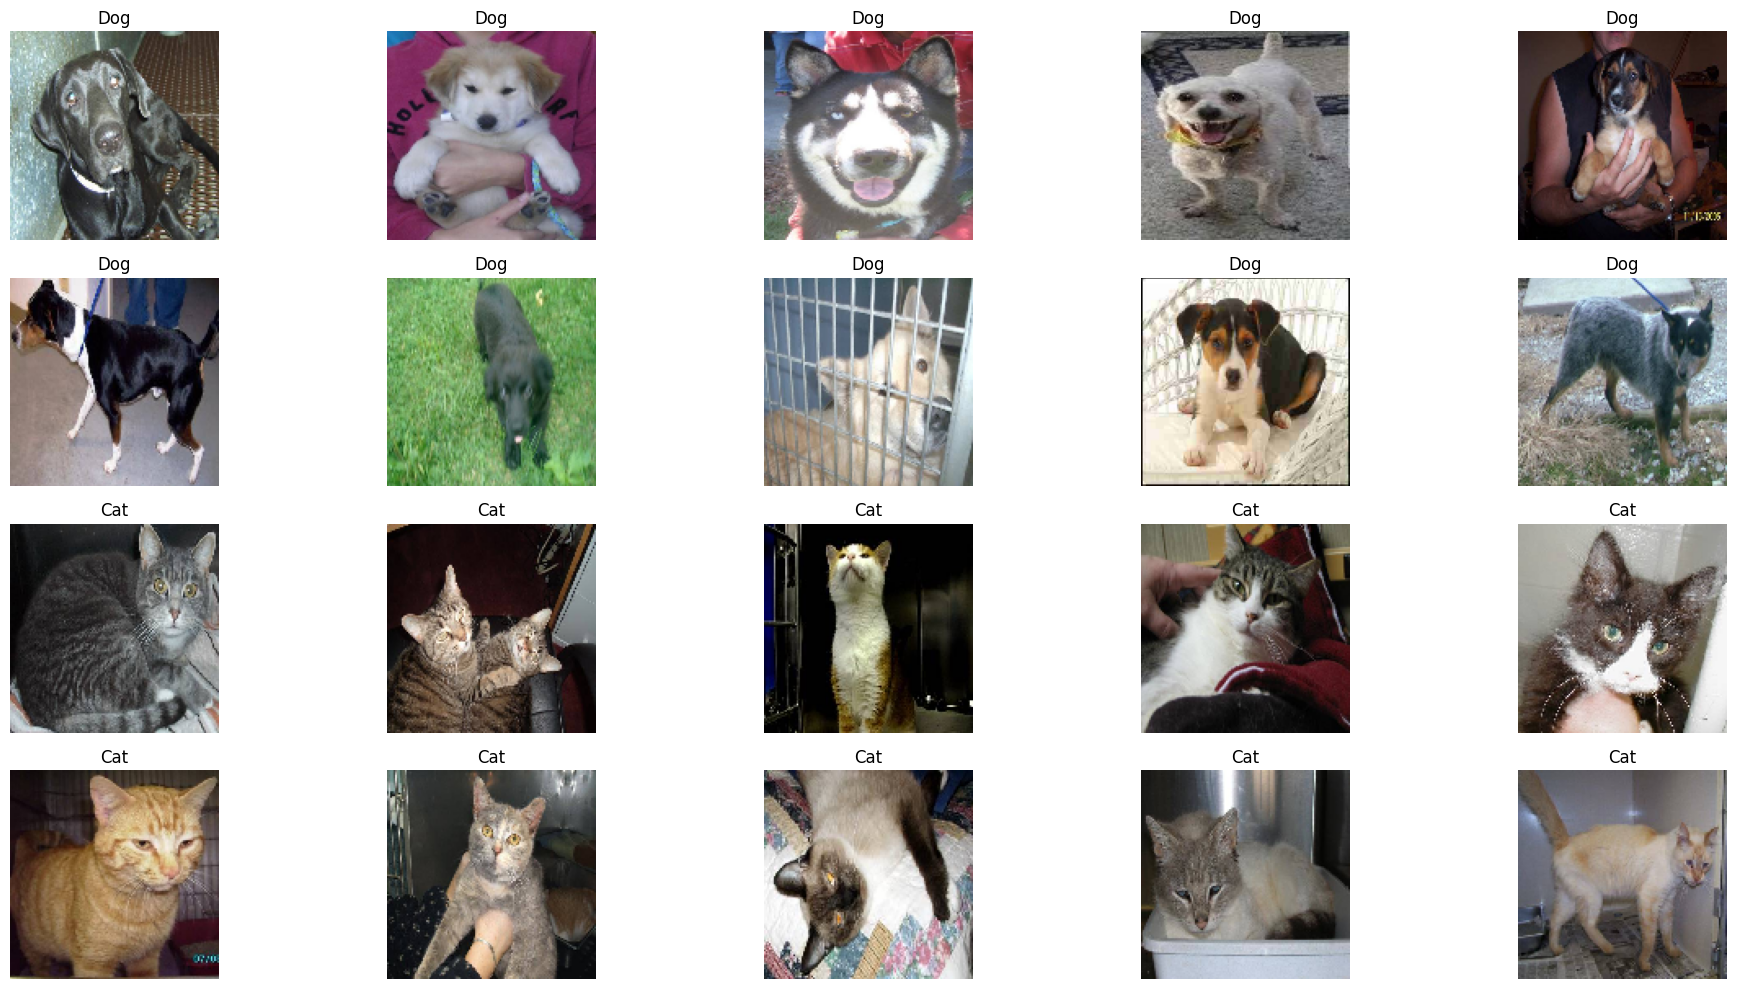

In [11]:
# Display the images
plt.figure(figsize=(20, 10))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    img = load_img(sample_images[i], target_size=(128, 128))
    plt.imshow(img)
    plt.axis('off')
    plt.title(sample_labels[i])
plt.tight_layout()
plt.show()

In [12]:
# Data preprocessing
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [13]:
val_datagen = ImageDataGenerator(rescale=1.0/255)

In [20]:
train_generator = train_datagen.flow_from_directory(
    train_organized_dir,
    target_size=(128, 128),
    batch_size=64,
    class_mode='binary'
)

validation_generator = val_datagen.flow_from_directory(
    val_organized_dir,
    target_size=(128, 128),
    batch_size=64,
    class_mode='binary'
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [21]:
model_sequential = Sequential([

    # Block 1
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    # Block 2
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    # Block 3
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    # Block 4
    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(256, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    # Reduce spatial size
    GlobalAveragePooling2D(),

    # Classification head
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

In [22]:
model_sequential.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
model_sequential.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 224, 224, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 112, 112, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 56, 56, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 28, 28, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │              

 Total params: 1,256,481 (4.79 MB)

 Trainable params: 1,255,521 (4.79 MB)

 Non-trainable params: 960 (3.75 KB)

In [24]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [25]:
history = model_sequential.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 845s 3s/step - accuracy: 0.6161 - loss: 0.6654 - val_accuracy: 0.5792 - val_loss: 0.6755
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 861s 3s/step - accuracy: 0.7049 - loss: 0.5814 - val_accuracy: 0.6690 - val_loss: 0.6007
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 807s 3s/step - accuracy: 0.7499 - loss: 0.5213 - val_accuracy: 0.6294 - val_loss: 0.7527
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 726s 2s/step - accuracy: 0.7910 - loss: 0.4569 - val_accuracy: 0.7094 - val_loss: 0.5461
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 797s 3s/step - accuracy: 0.8295 - loss: 0.3980 - val_accuracy: 0.8042 - val_loss: 0.4412


In [39]:
history2 = model_sequential.fit(
    train_generator,
    validation_data=validation_generator,
    initial_epoch=5,
    epochs=10,
    callbacks=[early_stop],
    verbose=1
)

Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 856s 3s/step - accuracy: 0.8439 - loss: 0.3618 - val_accuracy: 0.8344 - val_loss: 0.3537
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 838s 3s/step - accuracy: 0.8640 - loss: 0.3164 - val_accuracy: 0.7252 - val_loss: 0.4843
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 827s 3s/step - accuracy: 0.8810 - loss: 0.2858 - val_accuracy: 0.8532 - val_loss: 0.3507
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 879s 3s/step - accuracy: 0.8939 - loss: 0.2625 - val_accuracy: 0.8280 - val_loss: 0.3878
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 893s 3s/step - accuracy: 0.8993 - loss: 0.2444 - val_accuracy: 0.9004 - val_loss: 0.2310


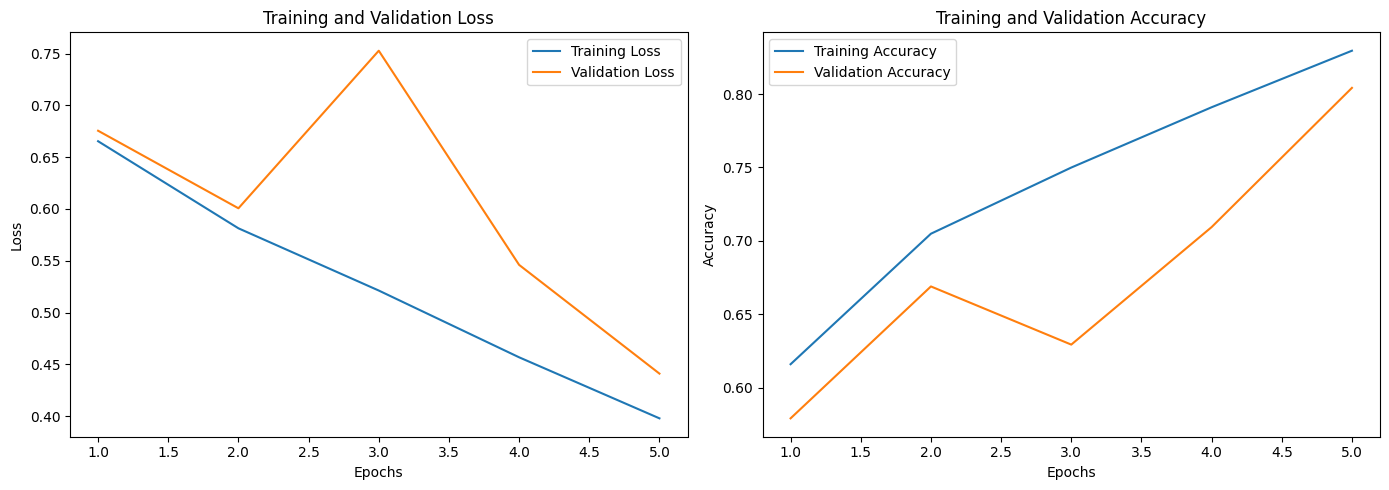

In [40]:
# Plot training and validation loss
epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(14, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['loss'], label='Training Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [41]:
# Randomly select 10 images from each class in the validation set
num_samples_per_class = 10

dog_val_images = np.random.choice(
    os.listdir(os.path.join(val_organized_dir, 'dogs')),
    num_samples_per_class,
    replace=False
)
cat_val_images = np.random.choice(
    os.listdir(os.path.join(val_organized_dir, 'cats')),
    num_samples_per_class,
    replace=False
)

img_paths = []
true_label_names = []

for img_name in dog_val_images:
    img_paths.append(os.path.join(val_organized_dir, 'dogs', img_name))
    true_label_names.append('dogs')

for img_name in cat_val_images:
    img_paths.append(os.path.join(val_organized_dir, 'cats', img_name))
    true_label_names.append('cats')

img_arrays = []
for img_path in img_paths:
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_arrays.append(img_array)

img_arrays = np.array(img_arrays)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step


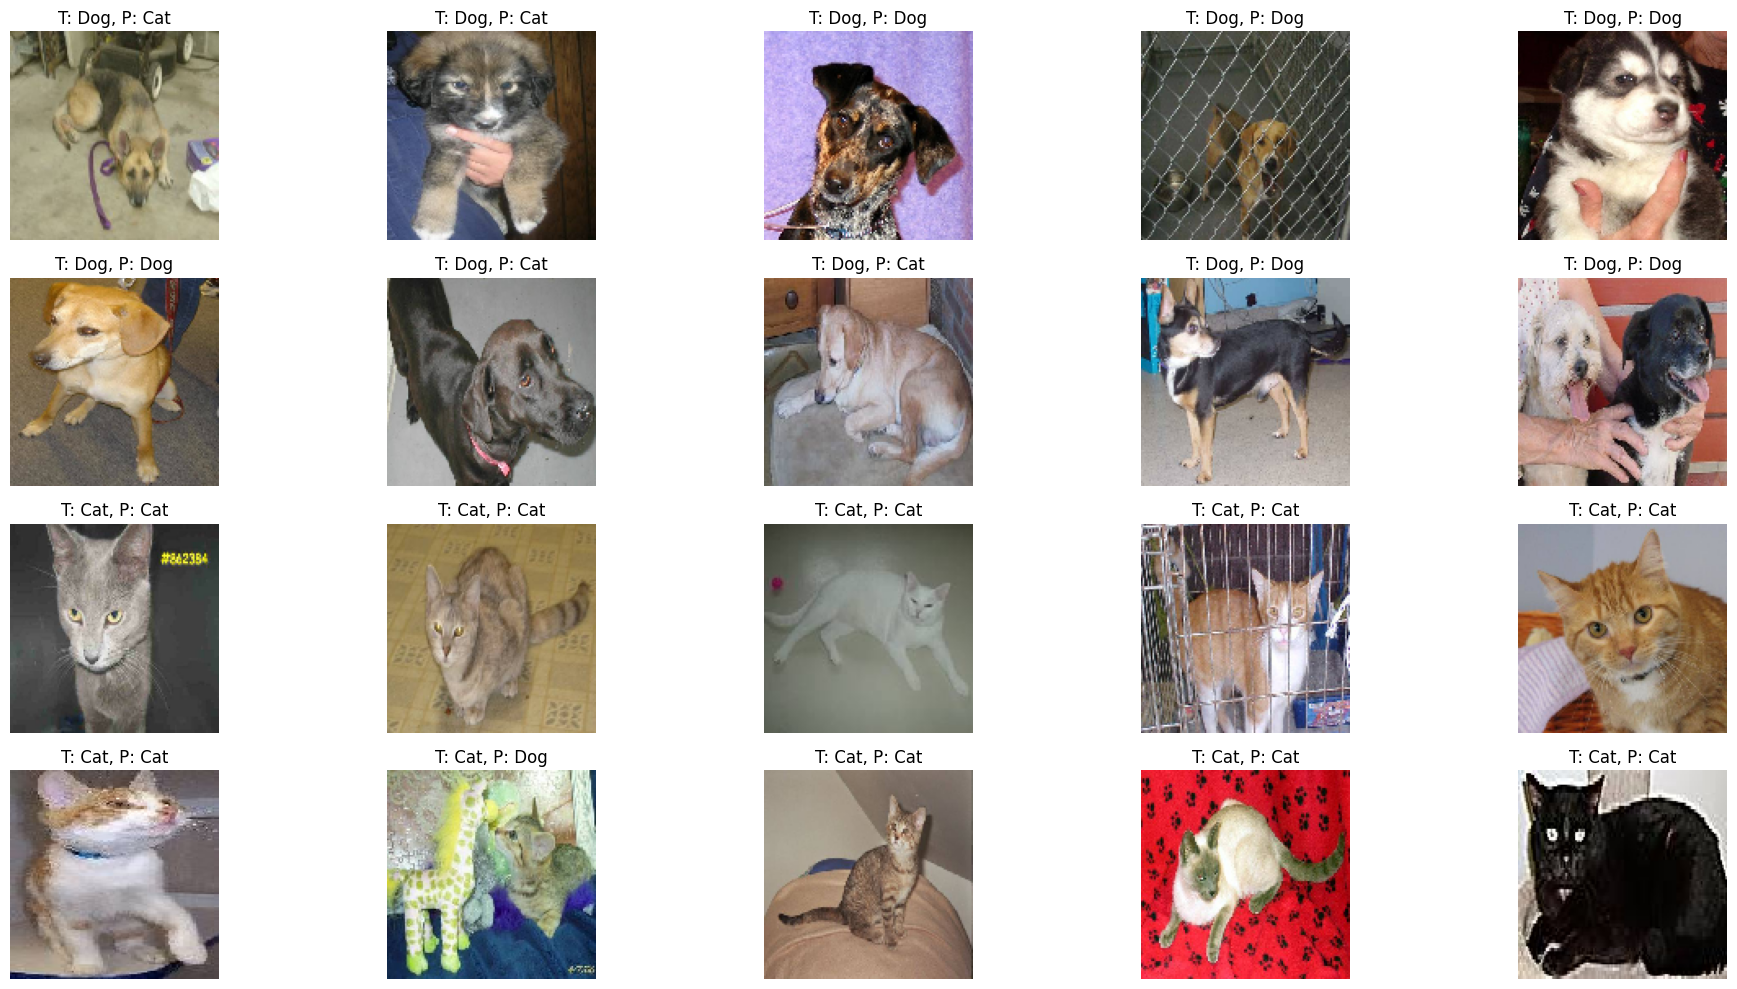

In [42]:
# Predict using the model
predictions = model_sequential.predict(img_arrays)
predicted_binary = (predictions > 0.5).astype(int).flatten()

index_to_class = {v: k for k, v in train_generator.class_indices.items()}
predicted_label_names = [index_to_class[i] for i in predicted_binary]

plt.figure(figsize=(20, 10))
for i in range(len(img_paths)):
    plt.subplot(4, 5, i + 1)
    img = load_img(img_paths[i], target_size=(128, 128))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"T: {true_label_names[i][:-1].title()}, P: {predicted_label_names[i][:-1].title()}")
plt.tight_layout()
plt.show()


In [43]:
# Generate predictions on the entire validation dataset
validation_generator.reset()
predictions = model_sequential.predict(validation_generator, verbose=1)
predicted_labels = (predictions > 0.5).astype(int).flatten()
true_labels = validation_generator.classes
class_names = list(validation_generator.class_indices.keys())

print("Class indices:", validation_generator.class_indices)


79/79 ━━━━━━━━━━━━━━━━━━━━ 48s 606ms/step
Class indices: {'cats': 0, 'dogs': 1}


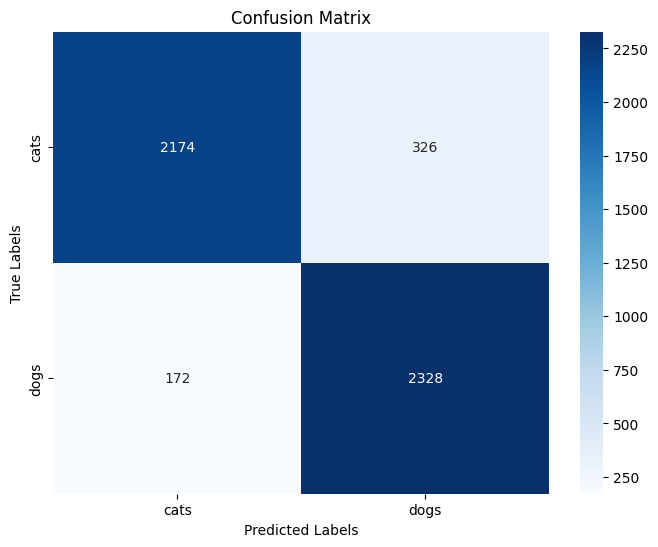

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [45]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

validation_datagen = ImageDataGenerator(rescale=1./255)

validation_generator = validation_datagen.flow_from_directory(
    val_organized_dir,
    target_size=(128, 128),
    batch_size=64,
    class_mode='binary',
    shuffle=False
)

print(validation_generator.class_indices)

Found 5000 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [46]:
validation_generator.reset()

predictions = model_sequential.predict(validation_generator)
predicted_labels = (predictions > 0.5).astype(int).reshape(-1)
true_labels = validation_generator.classes

from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(true_labels, predicted_labels))
print(classification_report(true_labels, predicted_labels, target_names=list(validation_generator.class_indices.keys())))

79/79 ━━━━━━━━━━━━━━━━━━━━ 48s 611ms/step
Accuracy: 0.9004
              precision    recall  f1-score   support

        cats       0.93      0.87      0.90      2500
        dogs       0.88      0.93      0.90      2500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000

